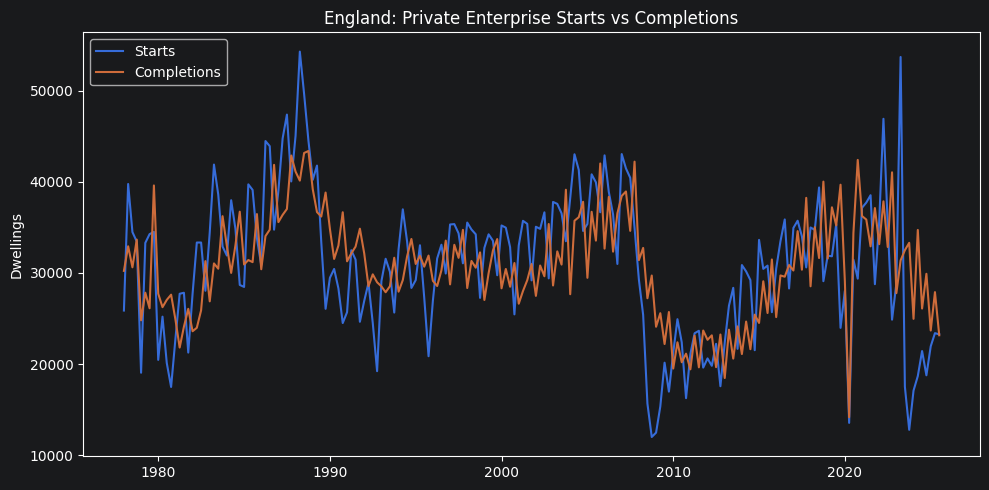

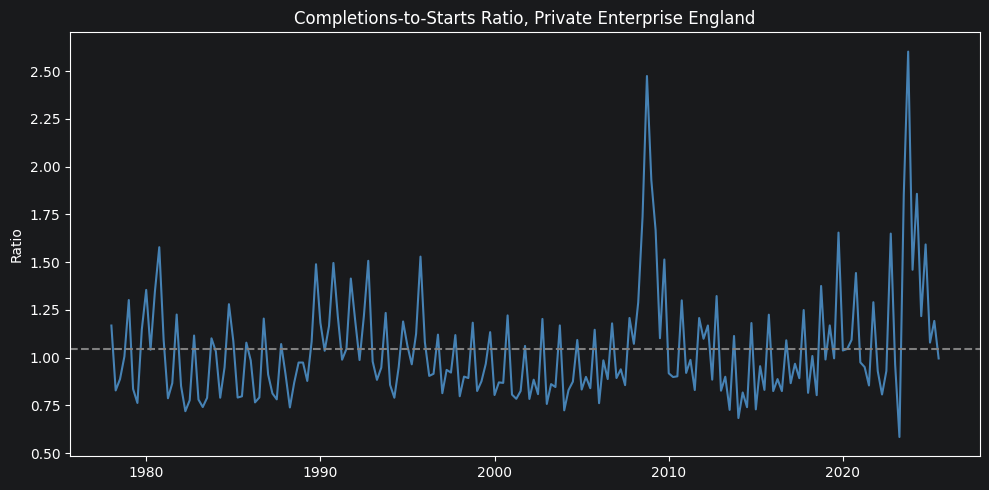

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the England quarterly sheet
df = pd.read_excel("../data/raw/ons_starts_completions_england.xlsx", sheet_name="1b", skiprows=5)

# Rename columns
df = df.rename(columns={
    "Period": "period",
    "Started - All Dwellings": "starts_all",
    "Started - Private Enterprise": "starts_private",
    "Completed - All Dwellings": "comp_all",
    "Completed - Private Enterprise": "comp_private"
})

df = df.dropna(subset=["period", "starts_all"])

# Parse quarter dates
df["year"] = df["period"].str.extract(r"(\d{4})").astype(int)
df["quarter"] = df["period"].apply(
    lambda x: 1 if "Jan" in x else 2 if "Apr" in x else 3 if "Jul" in x else 4
)
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + (df["quarter"]*3 - 2).astype(str) + "-01")
df["ratio_private"] = df["comp_private"] / df["starts_private"]

# Plot 1: Starts vs Completions
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["date"], df["starts_private"], label="Starts")
ax.plot(df["date"], df["comp_private"], label="Completions")
ax.set_title("England: Private Enterprise Starts vs Completions")
ax.set_ylabel("Dwellings")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/starts_vs_completions.png", dpi=150)
plt.show()

# Plot 2: Ratio over time
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["date"], df["ratio_private"], color="steelblue")
ax.axhline(df["ratio_private"].mean(), linestyle="--", color="grey")
ax.set_title("Completions-to-Starts Ratio, Private Enterprise England")
ax.set_ylabel("Ratio")
plt.tight_layout()
plt.savefig("../data/processed/ratio_plot.png", dpi=150)
plt.show()

In [3]:
files = {
    "starts_completions": "../data/raw/ons_starts_completions_england.xlsx",
    "obr_economy":        "../data/raw/obr_economy_march2026.xlsx",
    "net_additions":      "../data/raw/mhclg_net_additions_england.ods",
    "net_additions_reg":  "../data/raw/mhclg_net_additions_regional.ods",
    "epc":                "../data/raw/epc_new_builds.ods",
}

for name, path in files.items():
    print(f"\n{'='*60}")
    print(f"  {name}: {path}")
    print(f"{'='*60}")
    try:
        xls = pd.ExcelFile(path)
        print(f"Sheets: {xls.sheet_names}")
        for sheet in xls.sheet_names[:3]:  # first 3 sheets only
            df = pd.read_excel(path, sheet_name=sheet, nrows=5)
            print(f"\n  Sheet: {sheet}")
            print(f"  Columns: {df.columns.tolist()}")
            print(df.head())
    except Exception as e:
        print(f"  Error: {e}")


  starts_completions: ../data/raw/ons_starts_completions_england.xlsx
Sheets: ['Contents', 'Metadata', 'Source Information', 'Terms and Conditions', '1a', '1b', '1c', '1d', '1e', '1f', '2a', '2b', '2c', '2d', '2e', '3a', '3b', '3c', '3d', '3e']

  Sheet: Contents
  Columns: ['Indicators of house building, UK: permanent dwellings started and completed by country', 'Unnamed: 1']
  Indicators of house building, UK: permanent dwellings started and completed by country  \
0                                           Contents                                       
1                                           Metadata                                       
2                                 Source Information                                       
3                               Terms and Conditions                                       
4                   Quarterly (UK from Jan-Mar 1978)                                       

                                          Unnamed: 1  
0          

In [8]:
# OBR housing market tab
df = pd.read_excel("../data/raw/obr_economy_march2026.xlsx", sheet_name="1.16", nrows=10)
print("OBR 1.16 columns:", df.columns.tolist())
print(df.head(10))

print("\n" + "="*60)

# Net additions
df = pd.read_excel("../data/raw/mhclg_net_additions_england.ods",
                    sheet_name="LT120_unrounded", engine="odf", nrows=10)
print("Net additions columns:", df.columns.tolist())
print(df.head(10))

print("\n" + "="*60)

# EPC England
df = pd.read_excel("../data/raw/epc_new_builds.ods",
                    sheet_name="NB1_England_Only", engine="odf", nrows=10)
print("EPC columns:", df.columns.tolist())
print(df.head(10))

OBR 1.16 columns: ['Back to contents', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
   Back to contents           Unnamed: 1  \
0               NaN  1.16 Housing market   
1               NaN                  NaN   
2               NaN               2008Q1   
3               NaN               2008Q2   
4               NaN               2008Q3   
5               NaN               2008Q4   
6               NaN               2009Q1   
7               NaN               2009Q2   
8               NaN               2009Q3   
9               NaN               2009Q4   

                             Unnamed: 2  \
0                                   NaN   
1  House price index \n(Jan 2023 = 100)   
2                                  65.7   
3                                  64.2   
4                                    61   
5                                  57.6   
6                                  55.4   
7     